<a href="https://colab.research.google.com/github/Danielsarmiento24/SIMVIA/blob/Software/SIMVIA_Car_Detection_version_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 SIMVIA — Sistema Inteligente de Monitoreo Vehicular
## Comparación Experimental de Arquitecturas de Detección de Objetos

**Institución:** Escuela de Ingenierías Eléctrica, Electrónica y de Telecomunicaciones — UIS  
**Proyecto:** SIMVIA — Prototipo removible de monitoreo vehicular en tiempo real para la ciudad de Bucaramanga  
**Dataset:** Car Detection — Roboflow (1.000 imágenes, formato 640×640 px)
https://app.roboflow.com/simvia/car-detection-vciny-eg1o2/2  
**Hardware objetivo:** Raspberry Pi 5

---

## 🎯 Contexto y Objetivo

El **Plan Maestro de Movilidad de Bucaramanga 2022–2037** resalta la necesidad de contar con información granular sobre el comportamiento vehicular. SIMVIA responde a este reto mediante un prototipo portátil que emplea inteligencia artificial y visión computacional para detectar, clasificar y contabilizar vehículos en tiempo real, **sin almacenar imágenes ni videos**, garantizando así el cumplimiento de la Ley 1581 de 2012 sobre Protección de Datos Personales.

Este notebook tiene como propósito **justificar técnicamente la selección de la arquitectura** de detección de objetos más adecuada para el contexto del proyecto, cumpliendo con el objetivo específico del sistema:

> *"Diseñar e implementar algoritmos de procesamiento de imágenes basados en técnicas de visión computacional (YOLO u otros modelos de detección) para la identificación, conteo y clasificación de vehículos, así como para la estimación del flujo vehicular."*

**Restricción clave del sistema:** Precisión mínima del **85%** en detección y clasificación en tiempo real.

---

## 📌 Arquitecturas Evaluadas

| # | Sección | Familia | Tipo | Referencia |
|---|---|---|---|---|
| 0 | Setup | — | Instalación y dataset | — |
| 1 | YOLOv8 (n/s) | YOLO-CNN | Anchor-free CNN | Ultralytics, 2023 |
| 2 | YOLOv9 (t/s) | YOLO-CNN | GELAN + PGI | Wang et al., 2024 |
| 3 | YOLO11 (n/s) | YOLO-CNN | C3k2 + Atención espacial | Ultralytics, 2024 |
| 4 | YOLO26 (n/s) | YOLO-E2E | Sin NMS + MuSGD | Ultralytics, 2026 |
| 5 | RT-DETR-L | Transformer | Encoder Transformer | Baidu, 2023 |
| 6 | Ranking Final | — | Comparación y decisión | — |

---

> **Nota sobre el formato de imagen:** Todas las versiones de YOLO dentro del ecosistema Ultralytics (v8, v9, v11, v26) usan el mismo formato de entrenamiento `yolov8` de Roboflow y el tamaño estándar de **640×640 px**, para el cual fueron preentrenadas en MS COCO.

---
## ⚙️ Sección 0 — Instalación de Dependencias y Descarga del Dataset

### ¿Qué hace esta sección?
Instala las librerías del ecosistema Ultralytics y descarga el dataset de detección vehicular desde Roboflow. Se usan exactamente **1.000 imágenes** (sin aumentar el volumen) porque:
- Mayor cantidad incrementa drásticamente el tiempo de entrenamiento en Raspberry Pi 5
- El objetivo es comparar arquitecturas bajo las mismas condiciones controladas
- 1.000 imágenes a 640×640 px son suficientes para evaluar el comportamiento de cada modelo

El formato de descarga `yolov8` es el estándar de Ultralytics y es compatible con **todas** las arquitecturas evaluadas en este notebook: YOLOv8, YOLOv9, YOLO11, YOLO26 y RT-DETR.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# INSTALACIÓN DE DEPENDENCIAS
# ultralytics >= 8.4.0 requerido para soporte de YOLO26
# ─────────────────────────────────────────────────────────────────────────────
!pip install "ultralytics>=8.4.0" roboflow pandas psutil --quiet
print("✅ Dependencias instaladas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 77.3 MB/s eta 0:00:00
✅ Dependencias instaladas


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# VERIFICAR VERSIÓN DE ULTRALYTICS (debe ser >= 8.4.0 para YOLO26)
# ─────────────────────────────────────────────────────────────────────────────
import ultralytics
print(f"Ultralytics versión: {ultralytics.__version__}")

from packaging.version import Version
if Version(ultralytics.__version__) < Version("8.4.0"):
    raise RuntimeError("Se requiere ultralytics >= 8.4.0 para soporte de YOLO26. Reinicia el kernel.")
print("✅ Versión compatible con YOLO26")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics versión: 8.4.22
✅ Versión compatible con YOLO26


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DESCARGA DEL DATASET DESDE ROBOFLOW
#
# Formato 'yolov8': estándar Ultralytics compatible con YOLOv8, YOLOv9,
# YOLO11, YOLO26 y RT-DETR. NO existe un formato 'yolo26' en Roboflow;
# todas estas arquitecturas comparten el mismo pipeline de datos.
# ─────────────────────────────────────────────────────────────────────────────


from roboflow import Roboflow
rf = Roboflow(api_key="q40rGkgxL6W4TO7RU90B")
project = rf.workspace("simvia").project("car-detection-vciny-eg1o2")
version = project.version(2)
dataset = version.download("yolov8")


DATA_YAML = dataset.location + "/data.yaml"
TEST_IMAGES_PATH = dataset.location + "/test/images"

print(f"✅ Dataset descargado en: {dataset.location}")
print(f"📄 data.yaml: {DATA_YAML}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to car-detection-2 in yolov8:: 100%|██████████| 4778/4778 [00:00<00:00, 6431.52it/s]

✅ Dataset descargado en: /content/car-detection-2
📄 data.yaml: /content/car-detection-2/data.yaml


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTACIONES GLOBALES Y CONFIGURACIÓN COMPARTIDA
# Todos los modelos se entrenan con los mismos hiperparámetros para garantizar
# una comparación justa y reproducible.
# ─────────────────────────────────────────────────────────────────────────────
import os
import gc
import time
import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO
from IPython.display import display

# ── Hiperparámetros de entrenamiento (iguales para todos los modelos) ────────
EPOCHS  = 12    # Suficiente para validar convergencia con 1000 imágenes
IMGSZ   = 640   # Resolución estándar preentrenamiento YOLO
BATCH   = 16
N_INFER = 30    # Imágenes para medir latencia media de inferencia

# ── Proceso para medir consumo de RAM ────────────────────────────────────────
process = psutil.Process(os.getpid())

# ── Almacén global de resultados de todos los modelos ────────────────────────
ALL_RESULTS = []

print("✅ Configuración cargada")
print(f"   Épocas: {EPOCHS} | Resolución: {IMGSZ}px | Batch: {BATCH} | Inferencias: {N_INFER}")

✅ Configuración cargada
   Épocas: 12 | Resolución: 640px | Batch: 16 | Inferencias: 30


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIONES AUXILIARES COMPARTIDAS
# Estas funciones son reutilizadas por todas las secciones del notebook.
# ─────────────────────────────────────────────────────────────────────────────

def show_training_plots(model_name: str):
    """Muestra las gráficas de entrenamiento generadas por Ultralytics."""
    base = f"/content/runs/detect/{model_name}"
    plots = [
        ("results.png",          "Curvas de entrenamiento"),
        ("confusion_matrix.png", "Matriz de confusión"),
        ("BoxF1_curve.png",      "Curva F1"),
        ("BoxP_curve.png",       "Curva Precisión"),
        ("BoxR_curve.png",       "Curva Recall"),
    ]
    available = [(f"{base}/{f}", t) for f, t in plots if os.path.exists(f"{base}/{f}")]
    if not available:
        print(f"⚠️ No se encontraron gráficas para {model_name}")
        return
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 5))
    if len(available) == 1:
        axes = [axes]
    for ax, (path, title) in zip(axes, available):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.suptitle(f"📊 {model_name.upper()} — Resultados de Entrenamiento",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def evaluate_model(model_name: str, weight_path: str) -> dict:
    """
    Evalúa un modelo entrenado sobre el test set.
    Retorna un diccionario completo con métricas de calidad,
    velocidad y consumo de recursos.

    NOTA TÉCNICA — YOLO26 con cabezal E2E:
    YOLO26 usa por defecto inferencia end-to-end sin NMS.
    La validación con model.val() es compatible sin cambios adicionales.
    """
    if not os.path.exists(weight_path):
        print(f"❌ Peso no encontrado: {weight_path}")
        return None

    gc.collect()
    ram_before = process.memory_info().rss / (1024 ** 2)
    model = YOLO(weight_path)
    ram_after_load = process.memory_info().rss / (1024 ** 2)

    # ── Parámetros reales del modelo ─────────────────────────────────────────
    num_params = sum(p.numel() for p in model.model.parameters())

    # ── Validación sobre test set ─────────────────────────────────────────────
    val = model.val(data=DATA_YAML, split="test", verbose=False)
    m = val.results_dict

    map50   = m["metrics/mAP50(B)"]
    map5095 = m["metrics/mAP50-95(B)"]
    prec    = m["metrics/precision(B)"]
    rec     = m["metrics/recall(B)"]
    f1 = 2 * (prec * rec) / (prec + rec + 1e-6)

    # ── Métricas desde la matriz de confusión ─────────────────────────────────
    # La última fila/columna de la matriz corresponde al fondo (background)
    conf_matrix = val.confusion_matrix.matrix
    TP = np.diag(conf_matrix)[:-1].sum()
    FN = conf_matrix[:-1, -1].sum()
    FP = conf_matrix[-1, :-1].sum()

    pct_captura = (TP / (TP + FN + 1e-6)) * 100  # Recall real del conteo
    pct_falsos  = (FP / (TP + FP + 1e-6)) * 100  # Tasa de falsos positivos

    # ── Medición de latencia de inferencia ────────────────────────────────────
    test_imgs = sorted([
        os.path.join(TEST_IMAGES_PATH, f)
        for f in os.listdir(TEST_IMAGES_PATH)
        if f.endswith((".jpg", ".png"))
    ])

    for _ in range(5):  # Warmup: descarta los primeros resultados
        model(test_imgs[0], verbose=False)

    latencies = []
    for img in test_imgs[:N_INFER]:
        t0 = time.perf_counter()
        model(img, verbose=False)
        latencies.append((time.perf_counter() - t0) * 1000)

    avg_lat = np.mean(latencies)
    fps     = 1000 / avg_lat
    ram_total = process.memory_info().rss / (1024 ** 2)

    del model
    gc.collect()

    return {
        "Modelo":           model_name,
        "mAP50":            round(map50,   4),
        "mAP50-95":         round(map5095, 4),
        "Precision":        round(prec,    4),
        "Recall":           round(rec,     4),
        "F1":               round(f1,      4),
        "%Captura":         round(pct_captura, 2),
        "%FalsosPositivos": round(pct_falsos,  2),
        "TP":  int(TP), "FN": int(FN), "FP": int(FP),
        "Latencia_ms":      round(avg_lat, 2),
        "FPS":              round(fps,     2),
        "Parametros_M":     round(num_params / 1e6, 2),
        "RAM_modelo_MB":    round(ram_after_load - ram_before, 2),
        "RAM_total_MB":     round(ram_total, 2),
    }


def train_and_evaluate(model_name: str, weight: str, section_tag: str = ""):
    """Entrena un modelo, muestra sus gráficas y lo evalúa. Registra en ALL_RESULTS."""
    print(f"\n{'='*60}")
    print(f"  🔹 Entrenando {model_name} {section_tag}")
    print(f"{'='*60}")

    m = YOLO(weight)
    m.train(data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, name=model_name)
    del m
    gc.collect()

    show_training_plots(model_name)

    print(f"\n🔬 Evaluando {model_name} sobre test set...")
    result = evaluate_model(model_name,
                            f"/content/runs/detect/{model_name}/weights/best.pt")
    if result:
        ALL_RESULTS.append(result)
        display(pd.DataFrame([result]).set_index("Modelo"))
    return result


print("✅ Funciones auxiliares definidas")

✅ Funciones auxiliares definidas


---
## 🟦 Sección 1 — YOLOv8 (nano / small)

### ¿Qué es YOLOv8?

**YOLOv8** fue lanzado por Ultralytics en enero de 2023 y representa la primera versión con arquitectura **anchor-free** nativa dentro del ecosistema Ultralytics. Abandonó las anclas predefinidas de versiones anteriores para calcular directamente la posición y tamaño de las cajas desde cada píxel.

**Componentes clave de la arquitectura:**
- **Backbone C2f** (Cross Stage Partial con Feature Fusion): reemplaza el C3 de YOLOv5/v7, con conexiones más densas que mejoran el flujo de gradiente
- **Cabeza de detección desacoplada**: separa la rama de clasificación de la rama de regresión, lo que mejora la precisión de cada tarea
- **DFL** (Distribution Focal Loss): modela la distribución de probabilidad de las coordenadas de la caja, mejorando la localización de objetos
- **Neck PAN-FPN**: pirámide de características para detectar objetos a múltiples escalas

**Relevancia para SIMVIA en Raspberry Pi 5:**

| Variante | Parámetros | mAP50-95 COCO | CPU ONNX (ms) |
|---|---|---|---|
| yolov8n | ~3.2M | 37.3 | 80.4 |
| yolov8s | ~11.2M | 44.9 | 128.4 |

YOLOv8n es actualmente el modelo de referencia baseline para aplicaciones en dispositivos embebidos con esta familia.


  🔹 Entrenando yolov8n [Nano — ~3.2M params]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimiz

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


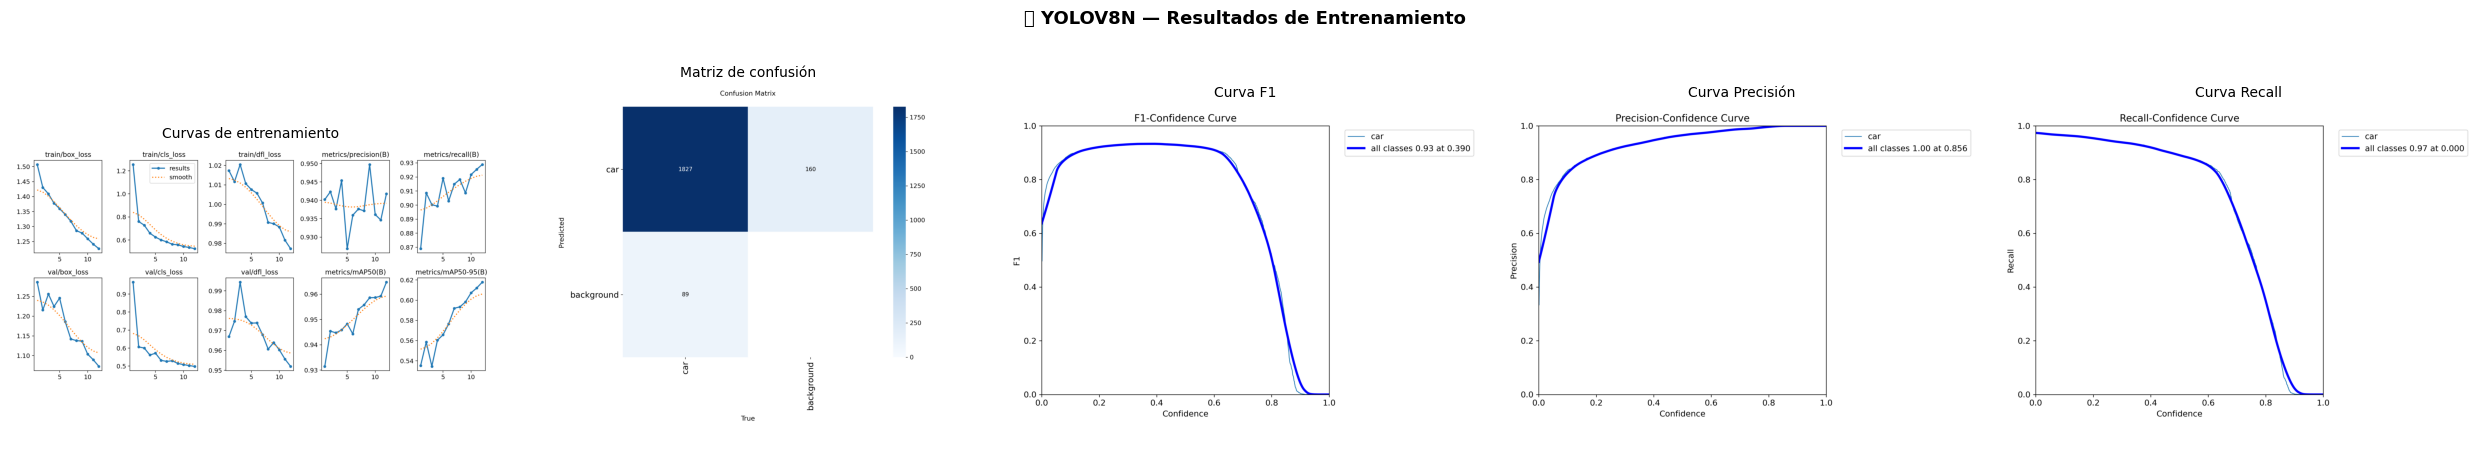


🔬 Evaluando yolov8n sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1508.1±446.6 MB/s, size: 57.5 KB)
val: Scanning /content/car-detection-2/test/labels... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.7Kit/s 0.1s
val: New cache created: /content/car-detection-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.6it/s 2.7s
                   all        100        916      0.955      0.907      0.951      0.608
Speed: 2.7ms preprocess, 4.5ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
yolov8n,0.9508,0.6082,0.9547,0.9072,0.9303,91.85,5.24,868,77,48,13.39,74.67,3.01,0.38,3398.57


{'Modelo': 'yolov8n',
 'mAP50': 0.9508,
 'mAP50-95': 0.6082,
 'Precision': 0.9547,
 'Recall': 0.9072,
 'F1': 0.9303,
 '%Captura': np.float64(91.85),
 '%FalsosPositivos': np.float64(5.24),
 'TP': 868,
 'FN': 77,
 'FP': 48,
 'Latencia_ms': np.float64(13.39),
 'FPS': np.float64(74.67),
 'Parametros_M': 3.01,
 'RAM_modelo_MB': 0.38,
 'RAM_total_MB': 3398.57}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — YOLOv8n
# Modelo nano: ~3.2M parámetros. Baseline ligero de la familia YOLOv8.
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("yolov8n", "yolov8n.pt", "[Nano — ~3.2M params]")


  🔹 Entrenando yolov8s [Small — ~11.2M params]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s, nbs=64, nms=False, opset=None, optimize=False, optim

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


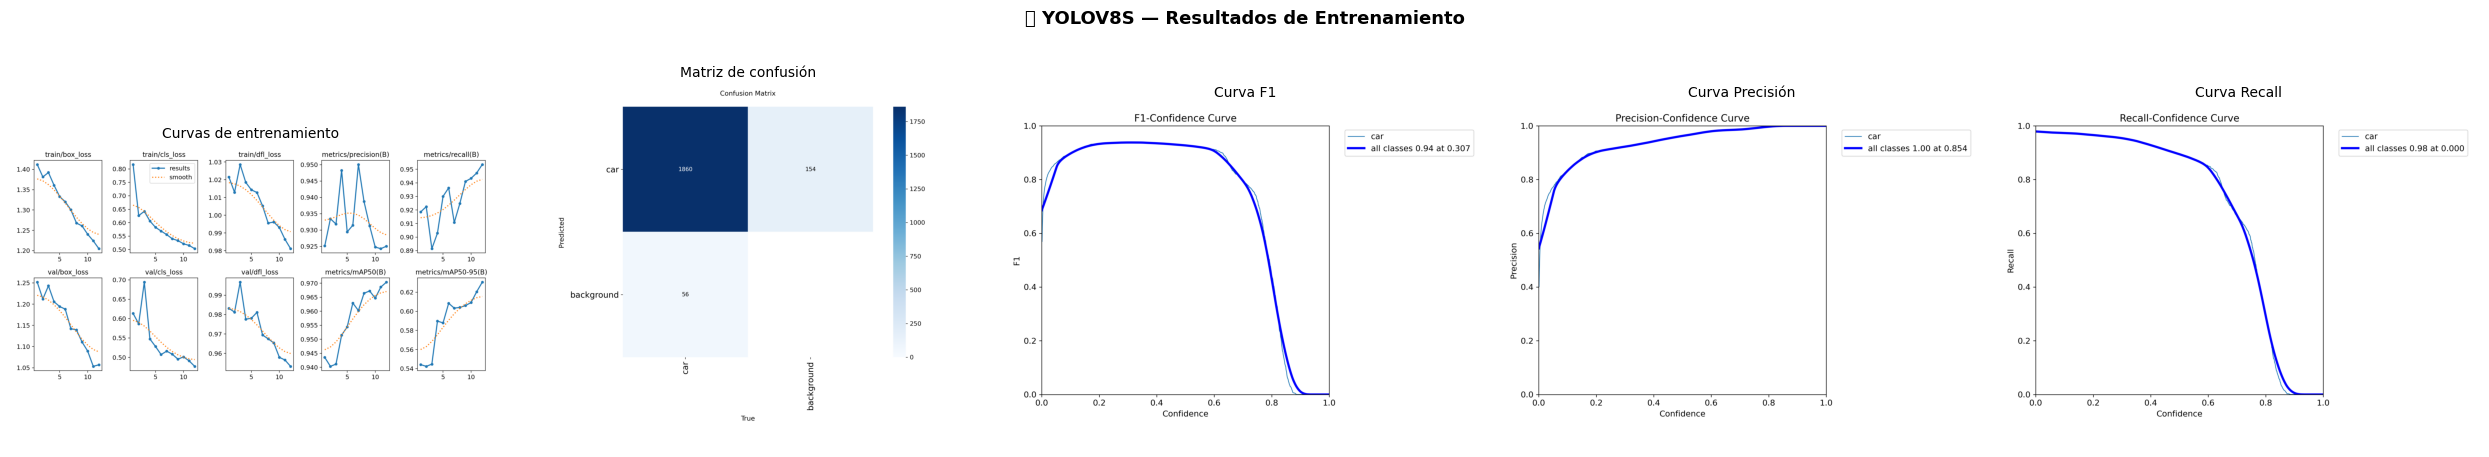


🔬 Evaluando yolov8s sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2094.0±751.8 MB/s, size: 57.3 KB)
val: Scanning /content/car-detection-2/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 5.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.5it/s 2.8s
                   all        100        916      0.934      0.927      0.957      0.623
Speed: 2.3ms preprocess, 6.3ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val2


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
yolov8s,0.9573,0.6235,0.9342,0.9269,0.9305,92.15,3.93,880,75,36,15.91,62.85,11.14,0.0,3571.33


{'Modelo': 'yolov8s',
 'mAP50': 0.9573,
 'mAP50-95': 0.6235,
 'Precision': 0.9342,
 'Recall': 0.9269,
 'F1': 0.9305,
 '%Captura': np.float64(92.15),
 '%FalsosPositivos': np.float64(3.93),
 'TP': 880,
 'FN': 75,
 'FP': 36,
 'Latencia_ms': np.float64(15.91),
 'FPS': np.float64(62.85),
 'Parametros_M': 11.14,
 'RAM_modelo_MB': 0.0,
 'RAM_total_MB': 3571.33}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — YOLOv8s
# Modelo small: ~11.2M parámetros. Mayor precisión que nano, aún viable
# para inferencia en Raspberry Pi 5 con latencias aceptables.
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("yolov8s", "yolov8s.pt", "[Small — ~11.2M params]")

---
## 🟩 Sección 2 — YOLOv9 (tiny / small)

### ¿Qué es YOLOv9?

**YOLOv9** fue publicado en febrero de 2024 por Chien-Yao Wang et al. (Universidad de Academia Sínica, Taiwán — los mismos autores de YOLOv7). Introduce dos conceptos que resuelven problemas fundamentales de las redes profundas.

**Innovaciones principales:**

1. **PGI — Programmable Gradient Information:** Las redes muy profundas sufren de pérdida de información durante la retropropagación (el gradiente se degrada al recorrer muchas capas). PGI agrega una **rama auxiliar reversible** durante el entrenamiento que garantiza que las capas finales reciban información completa del input original. Esta rama solo existe en entrenamiento; en inferencia no agrega costo.

2. **GELAN — Generalized Efficient Layer Aggregation Network:** Un nuevo backbone que generaliza las ideas de CSPNet y ELAN. Permite elegir qué bloques computacionales usar en cada etapa (convolucionales, transformers, etc.) manteniendo alta eficiencia de parámetros.

**Resultado en benchmarks:** YOLOv9t supera a YOLOv8n en mAP50-95 sobre MS COCO (38.3 vs 37.3) con un 24% menos de parámetros (~2.0M vs ~3.2M).

| Variante | Parámetros | mAP50-95 COCO | CPU ONNX (ms) |
|---|---|---|---|
| yolov9t | ~2.0M | 38.3 | 53.9 |
| yolov9s | ~7.1M | 46.8 | 102.7 |


  🔹 Entrenando yolov9t [Tiny — ~2.0M params]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9t.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9t, nbs=64, nms=False, opset=None, optimize=False, optimiz

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


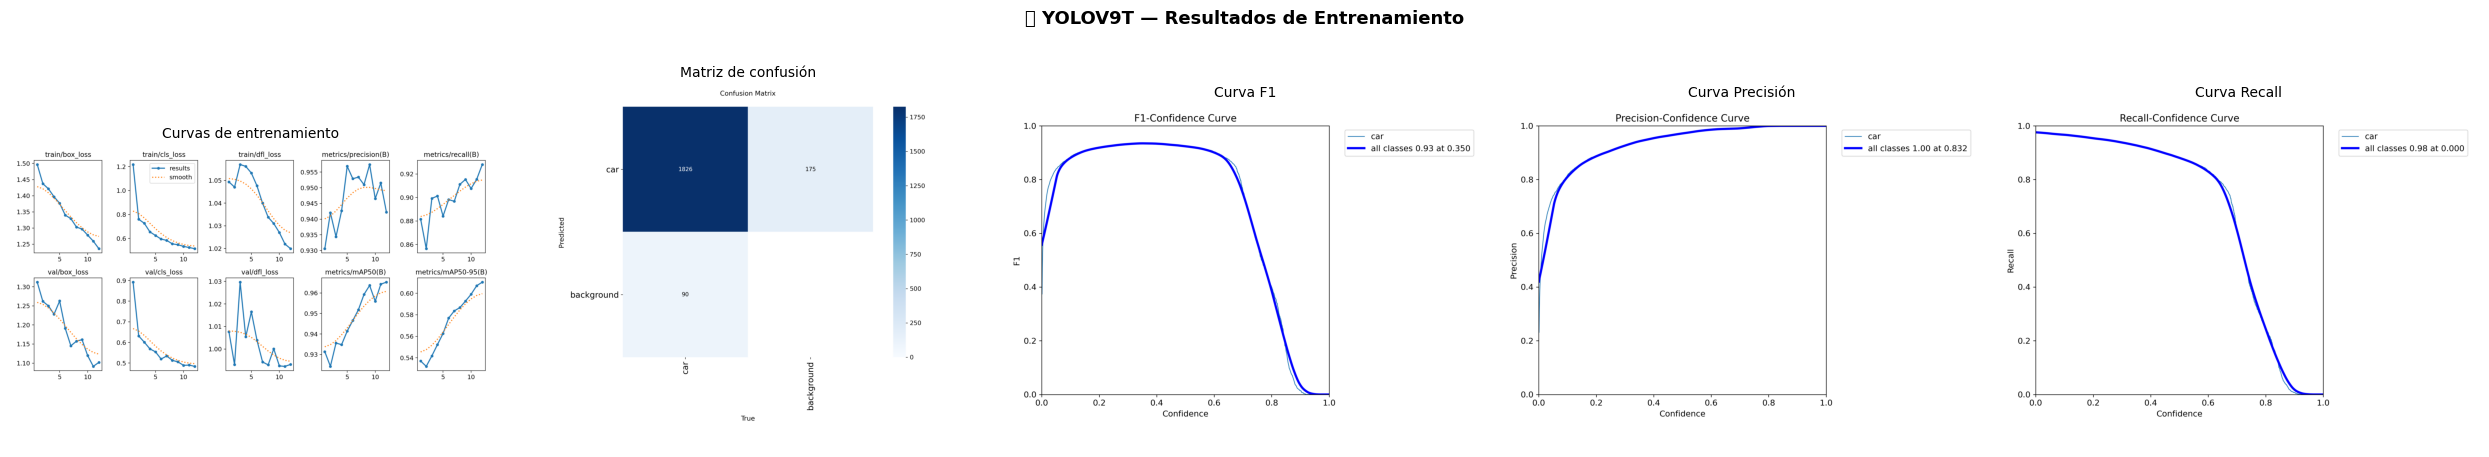


🔬 Evaluando yolov9t sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv9t summary (fused): 197 layers, 1,970,979 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2272.9±623.0 MB/s, size: 57.3 KB)
val: Scanning /content/car-detection-2/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 28.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.6it/s 2.7s
                   all        100        916      0.948      0.915      0.957      0.602
Speed: 3.3ms preprocess, 6.7ms inference, 0.0ms loss, 6.9ms postprocess per image
Results saved to /content/runs/detect/val3


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
yolov9t,0.9571,0.6019,0.9485,0.9148,0.9314,92.2,5.79,863,73,53,21.14,47.29,2.01,0.0,3693.49


{'Modelo': 'yolov9t',
 'mAP50': 0.9571,
 'mAP50-95': 0.6019,
 'Precision': 0.9485,
 'Recall': 0.9148,
 'F1': 0.9314,
 '%Captura': np.float64(92.2),
 '%FalsosPositivos': np.float64(5.79),
 'TP': 863,
 'FN': 73,
 'FP': 53,
 'Latencia_ms': np.float64(21.14),
 'FPS': np.float64(47.29),
 'Parametros_M': 2.01,
 'RAM_modelo_MB': 0.0,
 'RAM_total_MB': 3693.49}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — YOLOv9t
# Modelo tiny: ~2.0M parámetros. El más ligero de YOLOv9.
# Supera a yolov8n en mAP con MENOS parámetros gracias a GELAN + PGI.
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("yolov9t", "yolov9t.pt", "[Tiny — ~2.0M params]")


  🔹 Entrenando yolov9s [Small — ~7.1M params]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9s, nbs=64, nms=False, opset=None, optimize=False, optimi

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


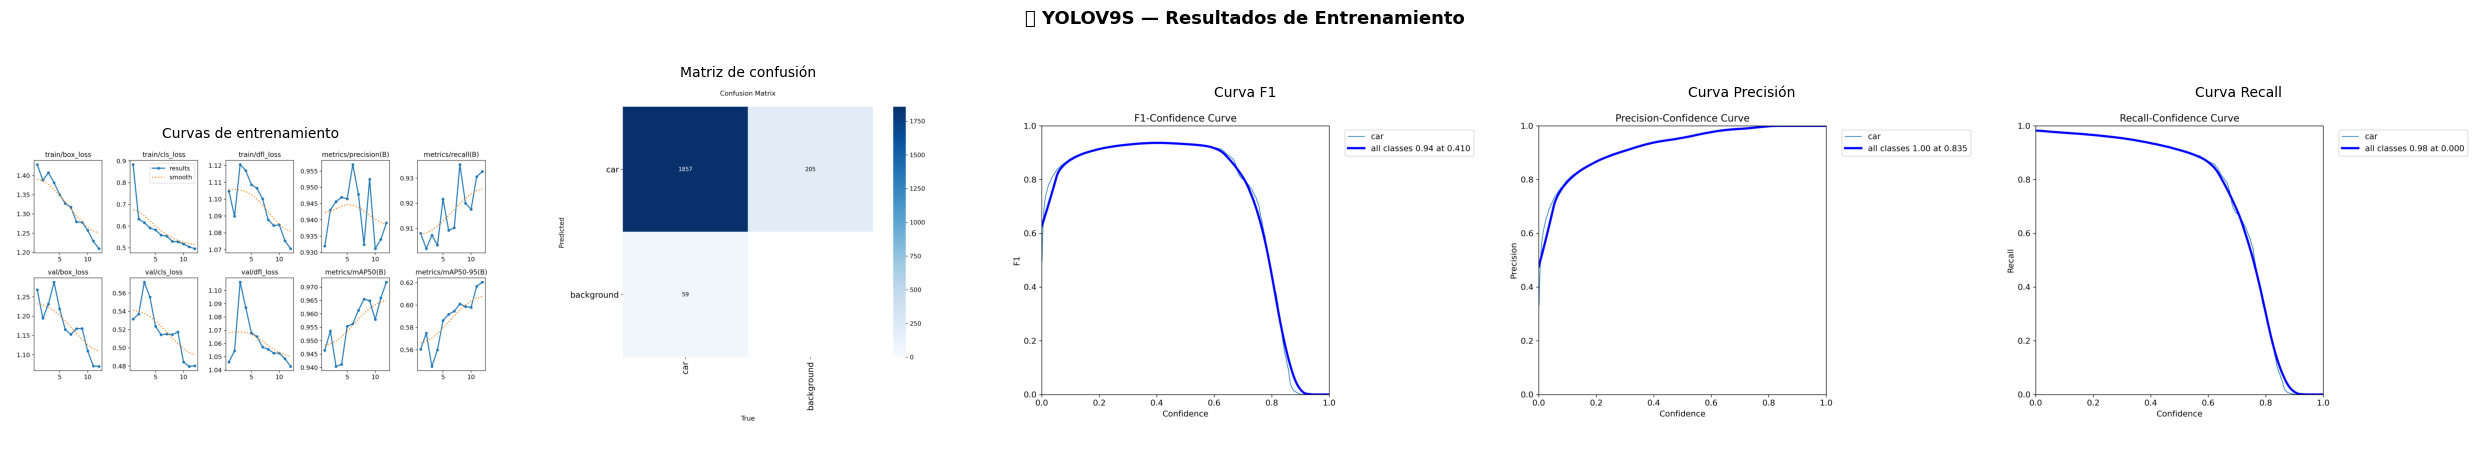


🔬 Evaluando yolov9s sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv9s summary (fused): 197 layers, 7,167,475 parameters, 0 gradients, 26.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1965.5±444.2 MB/s, size: 57.3 KB)
val: Scanning /content/car-detection-2/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 21.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.4it/s 2.9s
                   all        100        916      0.936       0.92      0.959      0.612
Speed: 3.0ms preprocess, 7.2ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to /content/runs/detect/val4


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
yolov9s,0.9591,0.6117,0.9356,0.9204,0.928,89.33,4.04,879,105,37,26.27,38.07,7.29,0.0,3796.09


{'Modelo': 'yolov9s',
 'mAP50': 0.9591,
 'mAP50-95': 0.6117,
 'Precision': 0.9356,
 'Recall': 0.9204,
 'F1': 0.928,
 '%Captura': np.float64(89.33),
 '%FalsosPositivos': np.float64(4.04),
 'TP': 879,
 'FN': 105,
 'FP': 37,
 'Latencia_ms': np.float64(26.27),
 'FPS': np.float64(38.07),
 'Parametros_M': 7.29,
 'RAM_modelo_MB': 0.0,
 'RAM_total_MB': 3796.09}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — YOLOv9s
# Modelo small: ~7.1M parámetros. Buen balance entre precisión y velocidad.
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("yolov9s", "yolov9s.pt", "[Small — ~7.1M params]")

---
## 🟨 Sección 3 — YOLO11 (nano / small)

### ¿Qué es YOLO11?

**YOLO11** fue lanzado por Ultralytics en octubre de 2024 como el **sucesor oficial de YOLOv8** dentro del ecosistema Ultralytics. A diferencia de YOLOv9 y YOLOv10 (desarrollados por equipos académicos externos), YOLO11 es el modelo de producción mantenido por el equipo de Ultralytics.

**Innovaciones arquitectónicas respecto a YOLOv8:**

- **Módulo C3k2** (Cross Stage Partial con kernel 2): versión más eficiente del C2f, reduce el número de operaciones manteniendo la capacidad de representación
- **Módulo C2PSA** (Cross Stage Partial with Spatial Attention): incorpora mecanismos de **atención espacial** en el neck sin el costo computacional de un Transformer completo. Permite al modelo enfocarse en regiones relevantes de la imagen
- **SPPF mejorado**: pooling espacial piramidal con soporte de atención

**Resultado:** YOLO11n logra un mAP50-95 de 39.5 en COCO con solo ~2.6M parámetros, superando a YOLOv8n (37.3, ~3.2M params) — un 6% más de precisión con un 19% menos de parámetros.

| Variante | Parámetros | mAP50-95 COCO | CPU ONNX (ms) |
|---|---|---|---|
| yolo11n | ~2.6M | 39.5 | 56.1 |
| yolo11s | ~9.4M | 47.0 | 90.0 |


  🔹 Entrenando yolo11n [Nano — ~2.6M params]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimiz

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


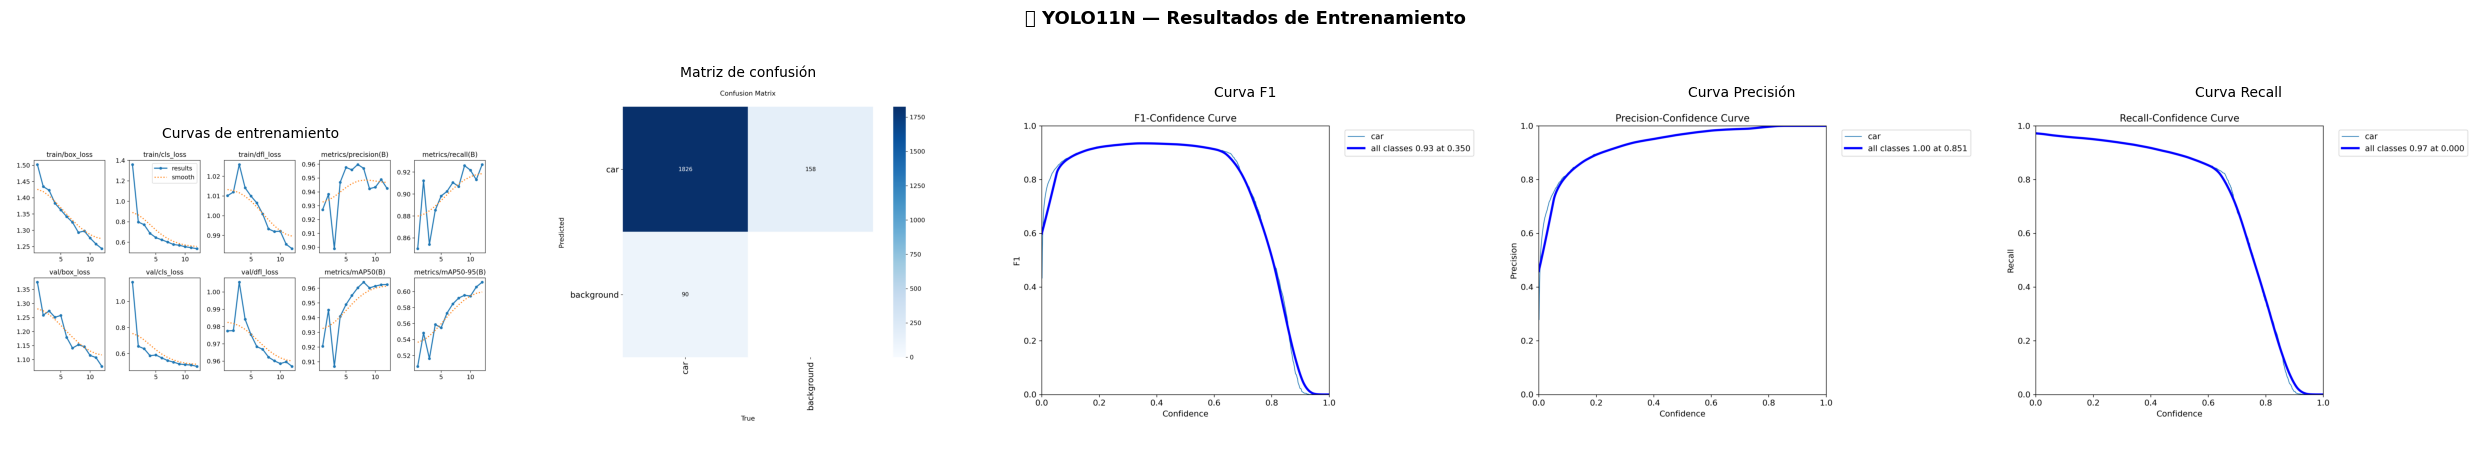


🔬 Evaluando yolo11n sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1402.5±397.5 MB/s, size: 57.3 KB)
val: Scanning /content/car-detection-2/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 26.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.6it/s 2.7s
                   all        100        916      0.941      0.912      0.944      0.602
Speed: 2.5ms preprocess, 8.2ms inference, 0.1ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val5


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
yolo11n,0.9444,0.6024,0.9408,0.9116,0.9259,91.75,5.24,868,78,48,14.06,71.14,2.59,0.0,3972.97


{'Modelo': 'yolo11n',
 'mAP50': 0.9444,
 'mAP50-95': 0.6024,
 'Precision': 0.9408,
 'Recall': 0.9116,
 'F1': 0.9259,
 '%Captura': np.float64(91.75),
 '%FalsosPositivos': np.float64(5.24),
 'TP': 868,
 'FN': 78,
 'FP': 48,
 'Latencia_ms': np.float64(14.06),
 'FPS': np.float64(71.14),
 'Parametros_M': 2.59,
 'RAM_modelo_MB': 0.0,
 'RAM_total_MB': 3972.97}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — YOLO11n
# Modelo nano: ~2.6M parámetros. Mejor que yolov8n en mAP con menos params.
# Arquitectura recomendada por Ultralytics para proyectos nuevos (2024–2025).
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("yolo11n", "yolo11n.pt", "[Nano — ~2.6M params]")


  🔹 Entrenando yolo11s [Small — ~9.4M params]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s, nbs=64, nms=False, opset=None, optimize=False, optimi

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


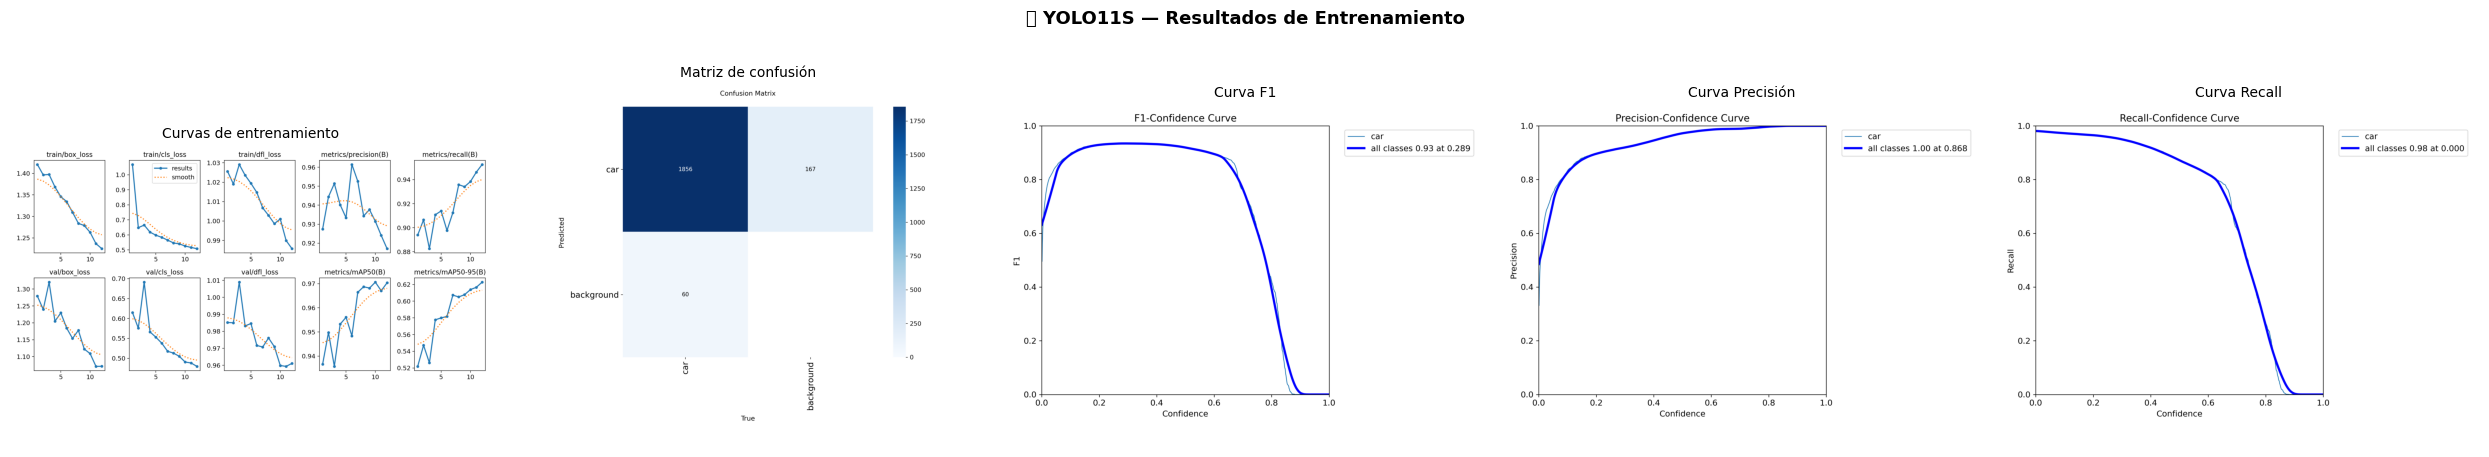


🔬 Evaluando yolo11s sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2218.2±649.7 MB/s, size: 57.3 KB)
val: Scanning /content/car-detection-2/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 30.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.5it/s 2.9s
                   all        100        916      0.925      0.942      0.962      0.617
Speed: 2.7ms preprocess, 6.3ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val6


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
yolo11s,0.9623,0.6174,0.9249,0.9421,0.9335,91.38,3.93,880,83,36,13.48,74.19,9.43,0.0,4199.87


{'Modelo': 'yolo11s',
 'mAP50': 0.9623,
 'mAP50-95': 0.6174,
 'Precision': 0.9249,
 'Recall': 0.9421,
 'F1': 0.9335,
 '%Captura': np.float64(91.38),
 '%FalsosPositivos': np.float64(3.93),
 'TP': 880,
 'FN': 83,
 'FP': 36,
 'Latencia_ms': np.float64(13.48),
 'FPS': np.float64(74.19),
 'Parametros_M': 9.43,
 'RAM_modelo_MB': 0.0,
 'RAM_total_MB': 4199.87}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — YOLO11s
# Modelo small: ~9.4M parámetros. Excelente precisión con baja latencia.
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("yolo11s", "yolo11s.pt", "[Small — ~9.4M params]")

---
## 🟪 Sección 4 — YOLO26 (nano / small)

### ¿Qué es YOLO26?

**YOLO26** fue lanzado por Ultralytics el **14 de enero de 2026** como la última evolución en la serie YOLO. Es el modelo más reciente de la familia y está diseñado específicamente para **dispositivos de borde y bajo consumo**, lo que lo hace directamente relevante para la Raspberry Pi 5 en el proyecto SIMVIA.

**Innovaciones que lo distinguen fundamentalmente de versiones anteriores:**

1. **Eliminación de DFL (Distribution Focal Loss):** YOLO26 elimina este módulo que, aunque eficaz, complicaba la exportación a formatos edge (TFLite, ONNX, OpenVINO) y limitaba la compatibilidad con hardware especializado. Al eliminarlo, la inferencia es más simple y portable.

2. **Arquitectura End-to-End nativa (sin NMS):** YOLO26 es el primer modelo de Ultralytics que es **nativo de extremo a extremo sin NMS** (Non-Maximum Suppression). Los detectores tradicionales (YOLOv8, v9, v11) requieren NMS como paso de postprocesamiento para eliminar detecciones duplicadas. YOLO26 tiene un **cabezal uno-a-uno** que produce directamente las predicciones finales, reduciendo latencia y simplificando el pipeline de inferencia.

3. **Optimizador MuSGD:** Combina SGD con el optimizador Muon (inspirado en los avances de Kimi K2 de Moonshot AI para LLMs), transfiriendo técnicas de optimización del aprendizaje profundo de lenguaje a visión artificial. Permite convergencia más rápida y estable.

4. **ProgLoss + STAL:** Funciones de pérdida mejoradas que aumentan la precisión en **objetos pequeños** — especialmente relevante en contextos de tráfico donde los vehículos distantes son pequeños en la imagen.

**Benchmark oficial de YOLO26 (COCO, CPU ONNX):**

| Variante | Parámetros | mAP50-95 | CPU ONNX (ms) | Velocidad CPU vs YOLO11 |
|---|---|---|---|---|
| yolo26n | 2.4M | 40.9 | 38.9 | **+44% más rápido** |
| yolo26s | 9.5M | 48.6 | 87.2 | **+3% más rápido** |

> **Relevancia crítica para Raspberry Pi 5:** YOLO26 fue diseñado específicamente para CPU sin GPU dedicada. La aceleración del 44% en CPU respecto a YOLO11n lo posiciona como el candidato más fuerte del estudio para implementación en hardware embebido.

**Compatibilidad:** Requiere `ultralytics >= 8.4.0`. Los pesos `yolo26n.pt` y `yolo26s.pt` se descargan automáticamente desde el repositorio oficial de Ultralytics.


  🔹 Entrenando yolo26n [Nano — 2.4M params | E2E sin NMS]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n, nbs=64, nms=False, opset=None, optimize=F

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


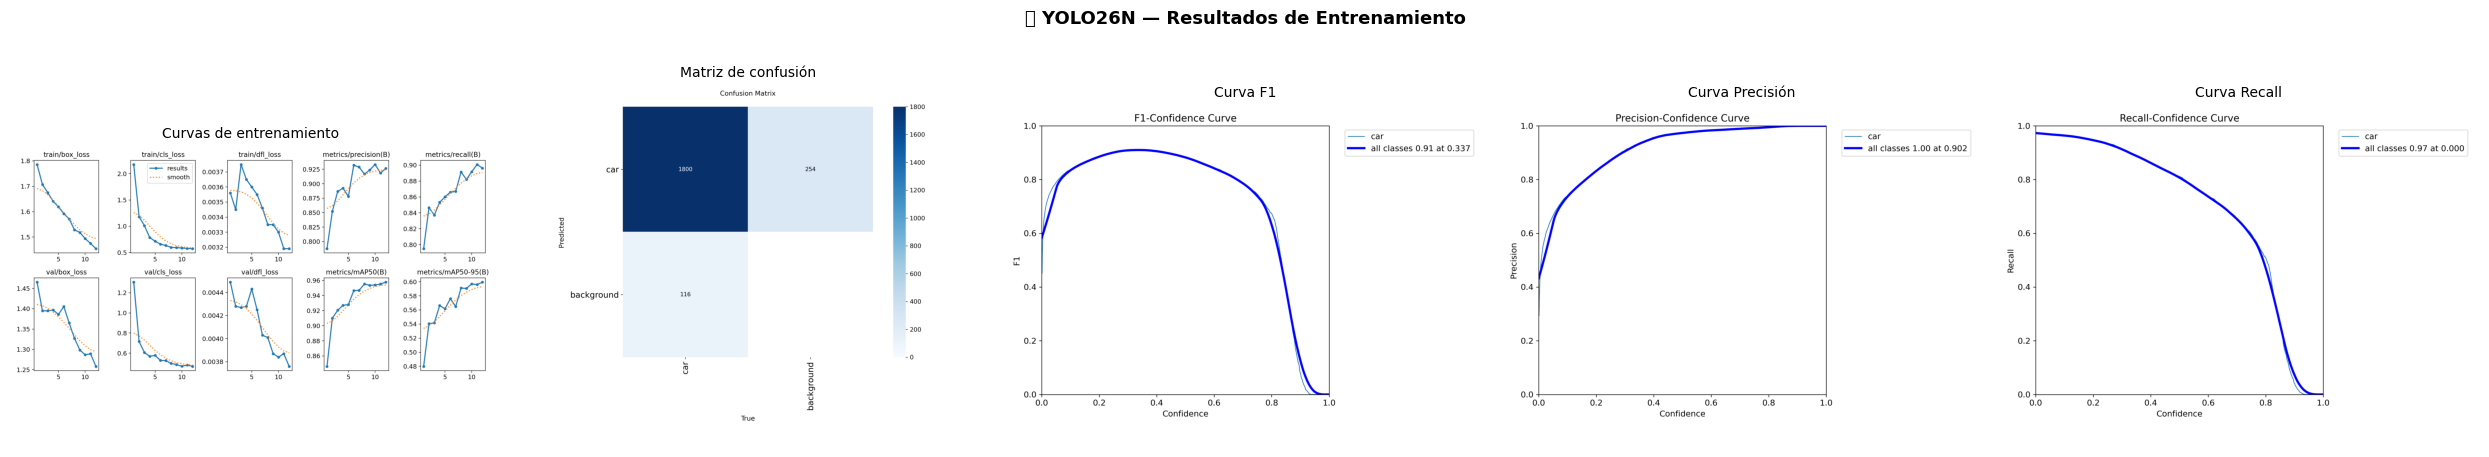


🔬 Evaluando yolo26n sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2037.7±822.5 MB/s, size: 57.3 KB)
val: Scanning /content/car-detection-2/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 30.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.6it/s 2.7s
                   all        100        916      0.911      0.884       0.94       0.59
Speed: 3.5ms preprocess, 4.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val7


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
yolo26n,0.9396,0.5903,0.9111,0.8844,0.8975,87.39,5.46,866,125,50,22.57,44.31,2.5,0.0,4206.23


{'Modelo': 'yolo26n',
 'mAP50': 0.9396,
 'mAP50-95': 0.5903,
 'Precision': 0.9111,
 'Recall': 0.8844,
 'F1': 0.8975,
 '%Captura': np.float64(87.39),
 '%FalsosPositivos': np.float64(5.46),
 'TP': 866,
 'FN': 125,
 'FP': 50,
 'Latencia_ms': np.float64(22.57),
 'FPS': np.float64(44.31),
 'Parametros_M': 2.5,
 'RAM_modelo_MB': 0.0,
 'RAM_total_MB': 4206.23}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — YOLO26n
#
# Modelo nano: 2.4M parámetros — el más liviano del estudio.
# Arquitectura E2E sin NMS + MuSGD. Diseñado para edge computing.
#
# NOTA: YOLO26 usa el mismo pipeline de Ultralytics. No se requiere ningún
# cambio en los argumentos de model.train() respecto a versiones anteriores.
# El cabezal E2E sin NMS está activo por defecto durante entrenamiento y
# validación.
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("yolo26n", "yolo26n.pt", "[Nano — 2.4M params | E2E sin NMS]")


  🔹 Entrenando yolo26s [Small — 9.5M params | E2E sin NMS]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s, nbs=64, nms=False, opset=None, optimize=

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


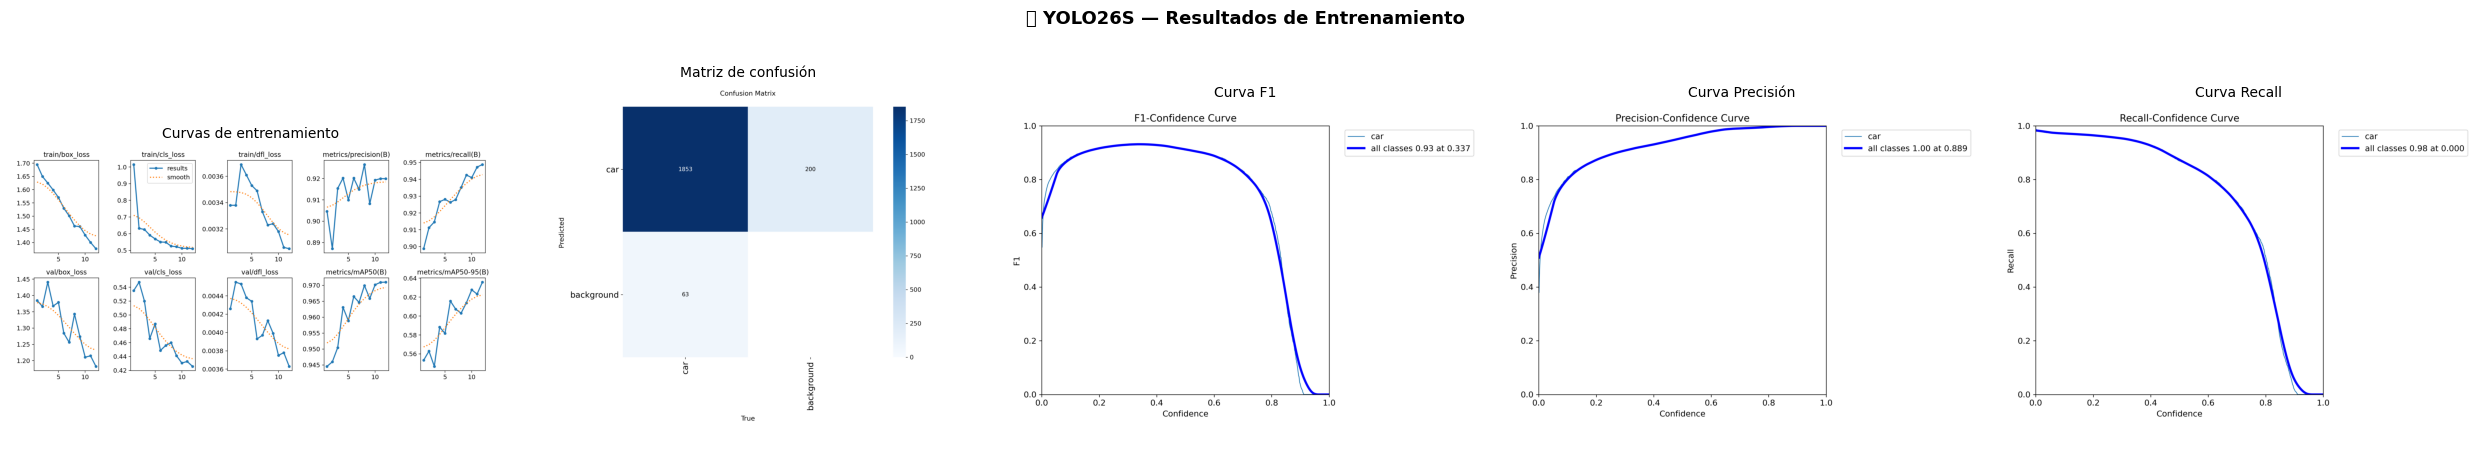


🔬 Evaluando yolo26s sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1861.7±773.7 MB/s, size: 57.3 KB)
val: Scanning /content/car-detection-2/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 32.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.4it/s 2.9s
                   all        100        916      0.907      0.941      0.959      0.631
Speed: 3.0ms preprocess, 6.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val8


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
yolo26s,0.959,0.6309,0.9067,0.941,0.9236,90.48,3.49,884,93,32,13.49,74.14,9.95,0.0,4235.21


{'Modelo': 'yolo26s',
 'mAP50': 0.959,
 'mAP50-95': 0.6309,
 'Precision': 0.9067,
 'Recall': 0.941,
 'F1': 0.9236,
 '%Captura': np.float64(90.48),
 '%FalsosPositivos': np.float64(3.49),
 'TP': 884,
 'FN': 93,
 'FP': 32,
 'Latencia_ms': np.float64(13.49),
 'FPS': np.float64(74.14),
 'Parametros_M': 9.95,
 'RAM_modelo_MB': 0.0,
 'RAM_total_MB': 4235.21}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — YOLO26s
#
# Modelo small: 9.5M parámetros.
# En benchmarks COCO supera a yolo11s (48.6 vs 47.0 mAP50-95) siendo
# ligeramente más rápido en CPU.
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("yolo26s", "yolo26s.pt", "[Small — 9.5M params | E2E sin NMS]")

---
## 🟥 Sección 5 — RT-DETR-L (Real-Time Detection Transformer)

### ¿Qué es RT-DETR y por qué incluirlo?

**RT-DETR** (Real-Time Detection Transformer) fue publicado por Baidu en 2023 y representa una arquitectura radicalmente diferente a YOLO. Es el único detector no-CNN de este estudio, incluido específicamente para:

1. **Evaluar el techo de precisión:** ¿Cuánta precisión extra ofrece un Transformer sobre los modelos YOLO ligeros?
2. **Justificar la elección de YOLO:** Demostrar empíricamente por qué YOLO es preferible para la Raspberry Pi 5 en condiciones de CPU sin GPU dedicada.

**¿Cómo funciona RT-DETR?**

A diferencia de YOLO (que divide la imagen en una cuadrícula y predice cajas por región), RT-DETR funciona así:

1. **Backbone CNN** (ResNet-50 en la variante L): extrae mapas de características a múltiples escalas
2. **Encoder Transformer eficiente**: modela relaciones **globales** entre todas las regiones de la imagen simultáneamente. Las CNN solo capturan contexto local; los Transformers capturan dependencias de largo alcance (ej: un vehículo parcialmente oculto puede detectarse considerando el contexto global del entorno)
3. **Decoder por consultas (Query-Based)**: en lugar de predecir en puntos de una cuadrícula, el modelo aprende un conjunto de N "consultas" entrenables que se transforman en detecciones finales
4. **Sin NMS nativo**: similar a YOLO26, RT-DETR produce directamente las detecciones sin postprocesamiento

**Limitación crítica para Raspberry Pi 5:**

| Modelo | Parámetros | mAP50-95 COCO | CPU ONNX (ms) |
|---|---|---|---|
| rtdetr-l | ~32M | 53.0 | ~778 ms |
| yolo26n (ref) | 2.4M | 40.9 | 38.9 ms |

RT-DETR-L es ~20x más lento en CPU que YOLO26n, lo que lo hace inviable para los **15 segundos de frecuencia de transmisión** requeridos por SIMVIA en condiciones de hardware sin GPU.


  🔹 Entrenando rtdetr-l [Large Transformer — ~32M params | Sin NMS]
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr-l, nbs=64, nms=False, opset=None

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       1/12      11.8G     0.6634     0.5718     0.1211         31        640: 100% ━━━━━━━━━━━━ 131/131 1.3s/it 2:47
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2s/it 8.5s
                   all        200       1916       0.92      0.924      0.948      0.569

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       2/12      12.3G     0.5186     0.4071    0.07185         29        640: 100% ━━━━━━━━━━━━ 131/131 1.2s/it 2:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.8it/s 4.0s
                   all        200       1916      0.926      0.933      0.959      0.596
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      11/12      12.3G     0.4293     0.3841     0.0653         23        640: 100% ━━━━━━━━━━━━ 131/131 1.1s/it 2:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.8it/s 3.9s
                   all        200       1916      0.922      0.963      0.975      0.625

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      12/12      12.4G     0.4242     0.3831    0.06642         29        640: 100% ━━━━━━━━━━━━ 131/131 1.1s/it 2:30
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.8it/s 3.9s
                   all        200       1916       0.91      0.967      0.974      0.621

12 epochs completed in 0.588 hours.
Optimizer stripped from /content/runs/detect/rtdetr-l/weights/last.pt, 66.2MB
Optimizer stripped from /content/runs/detect/rtdetr-l/weights/best.pt, 66.2MB

Validating /content/runs/detect/rtdetr-l/weights/best.pt...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2it/s 6.1s
                   all        200       1916      0.921      0.963      0.975      0.625
Speed: 0.2ms preprocess, 16.2ms infer

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


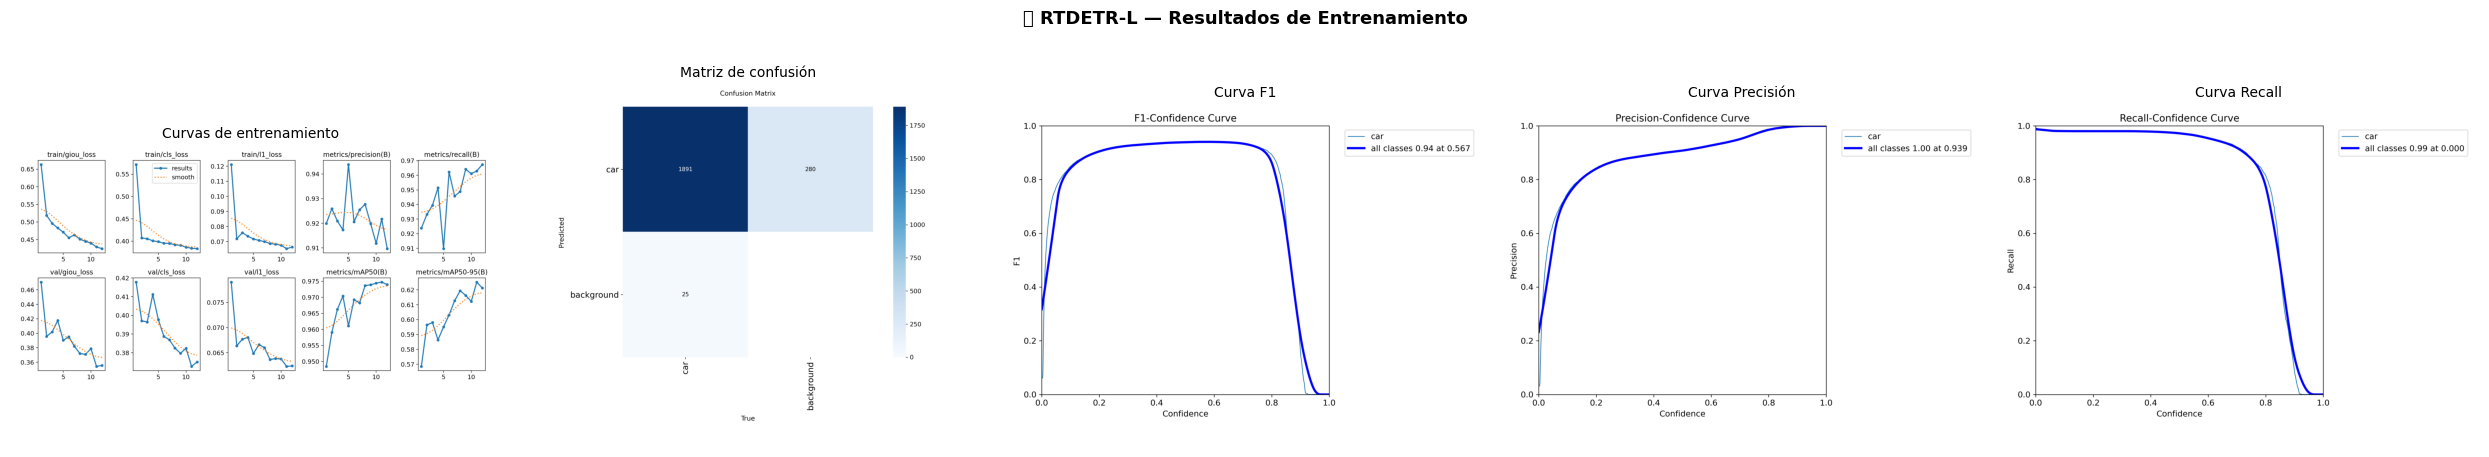


🔬 Evaluando rtdetr-l sobre test set...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1536.6±647.5 MB/s, size: 57.3 KB)
val: Scanning /content/car-detection-2/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 32.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2it/s 5.9s
                   all        100        916      0.926      0.941       0.96       0.61
Speed: 6.6ms preprocess, 45.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val9


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,TP,FN,FP,Latencia_ms,FPS,Parametros_M,RAM_modelo_MB,RAM_total_MB
Modelo,,,,,,,,,,,,,,,
rtdetr-l,0.9597,0.6098,0.9259,0.9414,0.9336,85.99,2.18,896,146,20,53.15,18.81,32.81,0.0,5506.47


{'Modelo': 'rtdetr-l',
 'mAP50': 0.9597,
 'mAP50-95': 0.6098,
 'Precision': 0.9259,
 'Recall': 0.9414,
 'F1': 0.9336,
 '%Captura': np.float64(85.99),
 '%FalsosPositivos': np.float64(2.18),
 'TP': 896,
 'FN': 146,
 'FP': 20,
 'Latencia_ms': np.float64(53.15),
 'FPS': np.float64(18.81),
 'Parametros_M': 32.81,
 'RAM_modelo_MB': 0.0,
 'RAM_total_MB': 5506.47}

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO Y EVALUACIÓN — RT-DETR-L
#
# Arquitectura Transformer. ~32M parámetros. Backbone ResNet-50.
# Incluido como referencia de precisión máxima no-CNN y para justificar
# por qué no es viable en Raspberry Pi 5 sin acelerador dedicado.
#
# Compatible con el mismo pipeline de Ultralytics (misma API que YOLO).
# ─────────────────────────────────────────────────────────────────────────────
train_and_evaluate("rtdetr-l", "rtdetr-l.pt",
                   "[Large Transformer — ~32M params | Sin NMS]")

---
## 🏆 Sección 6 — Evaluación Comparativa y Selección del Modelo Final

### ¿Qué hace esta sección?

Con los resultados de los **10 modelos** evaluados, esta sección construye:

1. **Tabla comparativa completa** — todas las métricas en un solo lugar
2. **Ranking objetivo ponderado** — basado en los criterios del proyecto SIMVIA
3. **Visualizaciones comparativas** — gráficas de barras y radar para cada dimensión
4. **Recomendación final justificada** — respaldada por los datos del experimento

### Metodología del ranking para SIMVIA

Los pesos del ranking reflejan directamente las **restricciones y criterios** definidos en el proyecto:

| Métrica | Peso | Justificación del proyecto SIMVIA |
|---|---|---|
| `%Captura` (Recall real) | **30%** | Restricción: ≥85% de precisión en conteo. No perder vehículos es crítico para datos de movilidad confiables |
| `mAP50-95` | **25%** | Precisión de localización global para clasificación correcta por tipo de vehículo |
| `FPS` | **25%** | Viabilidad de tiempo real en Raspberry Pi 5 (CPU, sin GPU). Restricción: transmisión cada 15 s |
| `Latencia_ms` (invertida) | **10%** | Menor latencia = más detecciones por segundo en condiciones de tráfico denso |
| `RAM_modelo_MB` (invertida) | **10%** | Raspberry Pi 5 tiene ~8 GB RAM compartida con el SO y otros procesos del sistema |

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TABLA COMPARATIVA COMPLETA DE TODOS LOS MODELOS
# ─────────────────────────────────────────────────────────────────────────────
df = pd.DataFrame(ALL_RESULTS)

print("\n📊 MÉTRICAS COMPLETAS POR MODELO — PROYECTO SIMVIA")
print("=" * 90)
display(
    df.set_index("Modelo")[
        ["mAP50", "mAP50-95", "Precision", "Recall", "F1",
         "%Captura", "%FalsosPositivos", "FPS", "Latencia_ms",
         "Parametros_M", "RAM_modelo_MB"]
    ]
)

# Verificar cuántos modelos superan la restricción del 85% de captura
print(f"\n🎯 Restricción SIMVIA: %Captura ≥ 85%")
aptos = df[df["%Captura"] >= 85.0][["Modelo", "%Captura", "mAP50-95", "FPS"]]
if len(aptos) > 0:
    print(f"   Modelos que cumplen la restricción ({len(aptos)}/{len(df)}):")
    display(aptos.set_index("Modelo"))
else:
    print("   ⚠️ Ningún modelo alcanzó el 85% con 12 épocas. Considerar más épocas.")


📊 MÉTRICAS COMPLETAS POR MODELO — PROYECTO SIMVIA


,mAP50,mAP50-95,Precision,Recall,F1,%Captura,%FalsosPositivos,FPS,Latencia_ms,Parametros_M,RAM_modelo_MB
Modelo,,,,,,,,,,,
yolov8n,0.9508,0.6082,0.9547,0.9072,0.9303,91.85,5.24,74.67,13.39,3.01,0.38
yolov8s,0.9573,0.6235,0.9342,0.9269,0.9305,92.15,3.93,62.85,15.91,11.14,0.00
yolov9t,0.9571,0.6019,0.9485,0.9148,0.9314,92.20,5.79,47.29,21.14,2.01,0.00
yolov9s,0.9591,0.6117,0.9356,0.9204,0.9280,89.33,4.04,38.07,26.27,7.29,0.00
yolo11n,0.9444,0.6024,0.9408,0.9116,0.9259,91.75,5.24,71.14,14.06,2.59,0.00
yolo11s,0.9623,0.6174,0.9249,0.9421,0.9335,91.38,3.93,74.19,13.48,9.43,0.00
yolo26n,0.9396,0.5903,0.9111,0.8844,0.8975,87.39,5.46,44.31,22.57,2.50,0.00
yolo26s,0.9590,0.6309,0.9067,0.9410,0.9236,90.48,3.49,74.14,13.49,9.95,0.00
rtdetr-l,0.9597,0.6098,0.9259,0.9414,0.9336,85.99,2.18,18.81,53.15,32.81,0.00



🎯 Restricción SIMVIA: %Captura ≥ 85%
   Modelos que cumplen la restricción (9/9):


,%Captura,mAP50-95,FPS
Modelo,,,
yolov8n,91.85,0.6082,74.67
yolov8s,92.15,0.6235,62.85
yolov9t,92.20,0.6019,47.29
yolov9s,89.33,0.6117,38.07
yolo11n,91.75,0.6024,71.14
yolo11s,91.38,0.6174,74.19
yolo26n,87.39,0.5903,44.31
yolo26s,90.48,0.6309,74.14
rtdetr-l,85.99,0.6098,18.81


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# RANKING OBJETIVO PONDERADO — METODOLOGÍA SIMVIA
#
# Para métricas donde MENOR es mejor (Latencia, RAM), se invierte la
# normalización antes de aplicar pesos:
#   norm_invertida = 1 - (valor - min) / (max - min)
# Esto garantiza que el score sea siempre positivo y comparable.
# ─────────────────────────────────────────────────────────────────────────────

RANKING_WEIGHTS = {
    "%Captura":      {"peso": 0.30, "mayor_es_mejor": True},
    "mAP50-95":      {"peso": 0.25, "mayor_es_mejor": True},
    "FPS":           {"peso": 0.25, "mayor_es_mejor": True},
    "Latencia_ms":   {"peso": 0.10, "mayor_es_mejor": False},
    "RAM_modelo_MB": {"peso": 0.10, "mayor_es_mejor": False},
}

norm = df.copy()
for col, cfg in RANKING_WEIGHTS.items():
    mn, mx = norm[col].min(), norm[col].max()
    rng = mx - mn + 1e-6
    if cfg["mayor_es_mejor"]:
        norm[col] = (norm[col] - mn) / rng
    else:
        norm[col] = 1 - (norm[col] - mn) / rng

norm["Score_Final"] = sum(
    norm[col] * cfg["peso"] for col, cfg in RANKING_WEIGHTS.items()
)

ranking = df.copy()
ranking["Score_Final"] = norm["Score_Final"].round(4)
ranking = ranking.sort_values("Score_Final", ascending=False).reset_index(drop=True)
ranking.index += 1

print("\n🏆 RANKING FINAL — Balance Precisión + Eficiencia para Raspberry Pi 5")
print("=" * 90)
display(
    ranking[
        ["Modelo", "mAP50", "mAP50-95", "%Captura", "F1",
         "FPS", "Latencia_ms", "Parametros_M", "RAM_modelo_MB", "Score_Final"]
    ]
)


🏆 RANKING FINAL — Balance Precisión + Eficiencia para Raspberry Pi 5


,Modelo,mAP50,mAP50-95,%Captura,F1,FPS,Latencia_ms,Parametros_M,RAM_modelo_MB,Score_Final
1,yolo26s,0.9590,0.6309,90.48,0.9236,74.14,13.49,9.95,0.00,0.9143
2,yolov8s,0.9573,0.6235,92.15,0.9305,62.85,15.91,11.14,0.00,0.8928
3,yolo11s,0.9623,0.6174,91.38,0.9335,74.19,13.48,9.43,0.00,0.8749
4,yolo11n,0.9444,0.6024,91.75,0.9259,71.14,14.06,2.59,0.00,0.7853
5,yolov8n,0.9508,0.6082,91.85,0.9303,74.67,13.39,3.01,0.38,0.7433
6,yolov9t,0.9571,0.6019,92.20,0.9314,47.29,21.14,2.01,0.00,0.6794
7,yolov9s,0.9591,0.6117,89.33,0.9280,38.07,26.27,7.29,0.00,0.5469
8,yolo26n,0.9396,0.5903,87.39,0.8975,44.31,22.57,2.50,0.00,0.3587
9,rtdetr-l,0.9597,0.6098,85.99,0.9336,18.81,53.15,32.81,0.00,0.2201


Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.


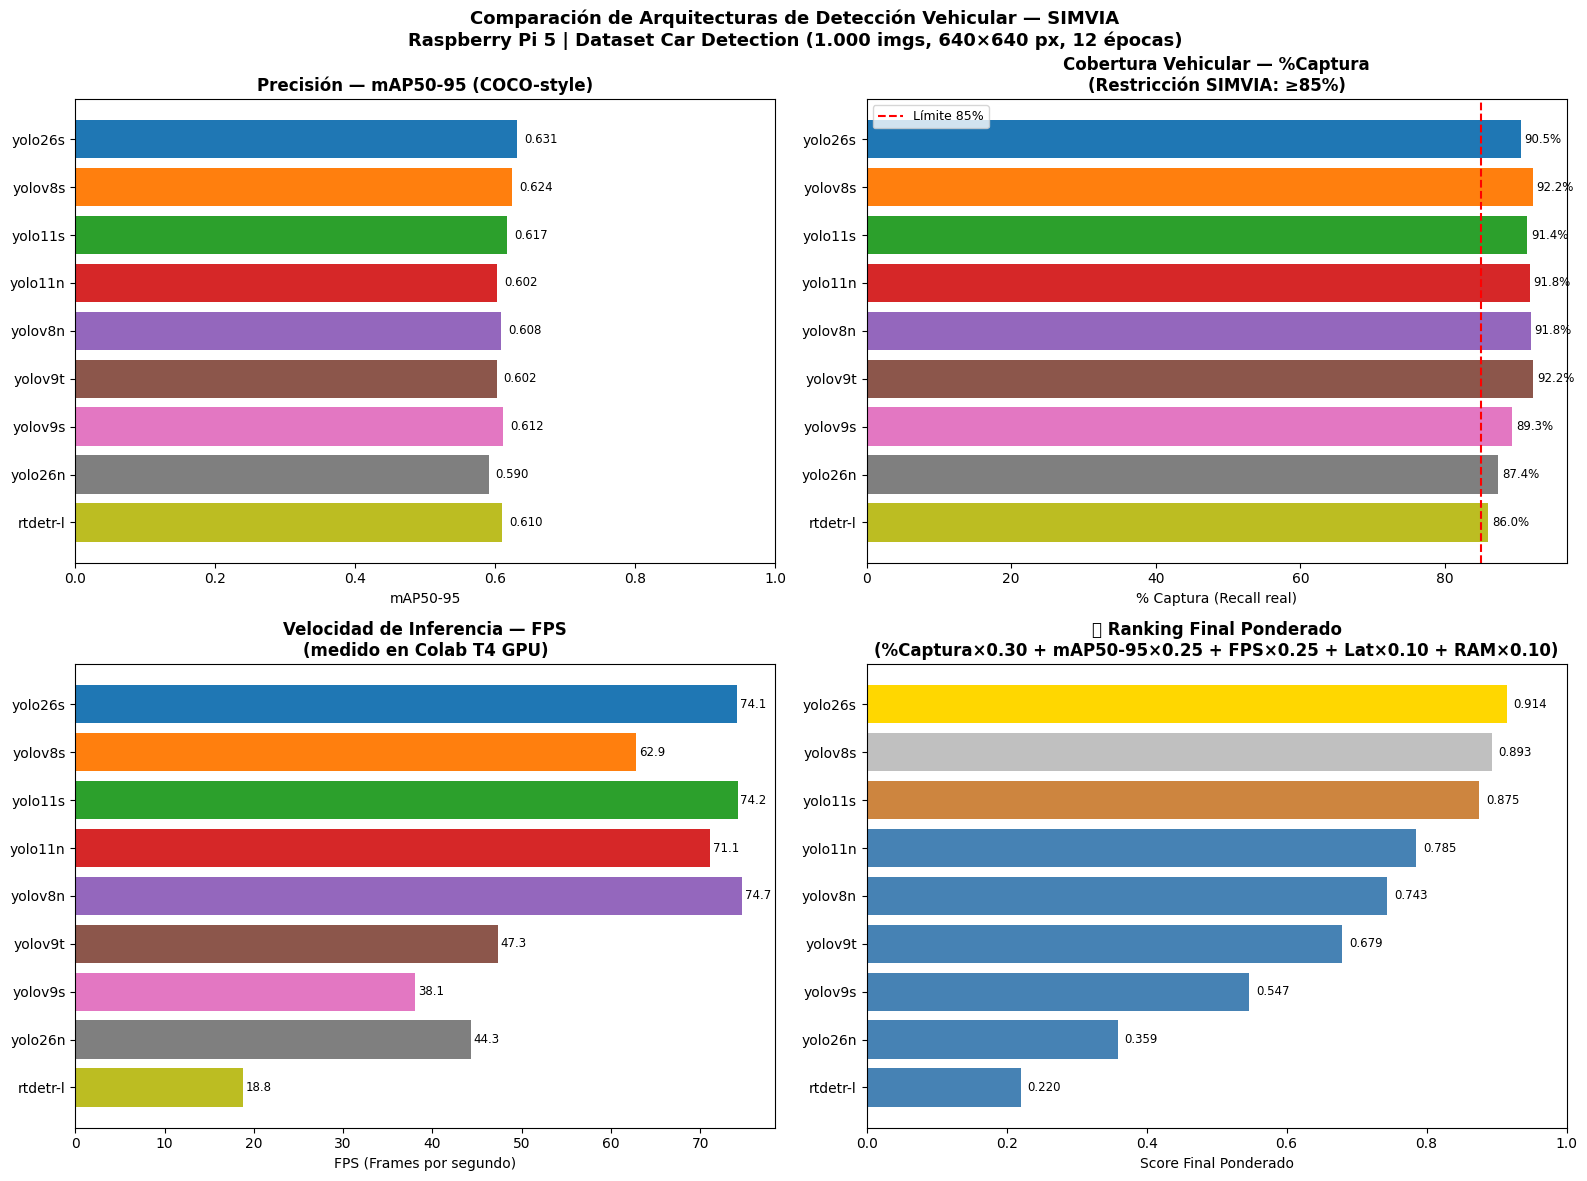

✅ Gráfica guardada en /content/SIMVIA_comparacion_modelos.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN COMPARATIVA — 4 DIMENSIONES
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Comparación de Arquitecturas de Detección Vehicular — SIMVIA\n"
    "Raspberry Pi 5 | Dataset Car Detection (1.000 imgs, 640×640 px, 12 épocas)",
    fontsize=13, fontweight="bold"
)

palette = plt.cm.tab10.colors
models  = ranking["Modelo"].tolist()
colors  = [palette[i % 10] for i in range(len(models))]

def hbar(ax, values, xlabel, title, fmt="{:.3f}", annotate_offset=0.01):
    bars = ax.barh(models, values, color=colors)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight="bold")
    ax.invert_yaxis()
    for bar, val in zip(bars, values):
        ax.text(val + annotate_offset, bar.get_y() + bar.get_height() / 2,
                fmt.format(val), va="center", fontsize=8.5)

# ── Panel 1: mAP50-95 ────────────────────────────────────────────────────────
hbar(axes[0, 0],
     ranking["mAP50-95"].tolist(),
     "mAP50-95",
     "Precisión — mAP50-95 (COCO-style)")
axes[0, 0].set_xlim(0, 1)

# ── Panel 2: %Captura ─────────────────────────────────────────────────────────
hbar(axes[0, 1],
     ranking["%Captura"].tolist(),
     "% Captura (Recall real)",
     "Cobertura Vehicular — %Captura\n(Restricción SIMVIA: ≥85%)",
     fmt="{:.1f}%",
     annotate_offset=0.5)
axes[0, 1].axvline(x=85, color="red", linestyle="--", linewidth=1.5,
                   label="Límite 85%")
axes[0, 1].legend(fontsize=9)

# ── Panel 3: FPS ──────────────────────────────────────────────────────────────
hbar(axes[1, 0],
     ranking["FPS"].tolist(),
     "FPS (Frames por segundo)",
     "Velocidad de Inferencia — FPS\n(medido en Colab T4 GPU)",
     fmt="{:.1f}",
     annotate_offset=0.3)

# ── Panel 4: Score Final ──────────────────────────────────────────────────────
podium_colors = ["gold", "silver", "peru"] + ["steelblue"] * max(0, len(models) - 3)
axes[1, 1].barh(models, ranking["Score_Final"].tolist(),
                color=podium_colors[:len(models)])
axes[1, 1].set_xlabel("Score Final Ponderado")
axes[1, 1].set_title(
    "🏆 Ranking Final Ponderado\n"
    "(%Captura×0.30 + mAP50-95×0.25 + FPS×0.25 + Lat×0.10 + RAM×0.10)",
    fontweight="bold"
)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlim(0, 1)
for bar, val in zip(axes[1, 1].patches, ranking["Score_Final"].tolist()):
    axes[1, 1].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=8.5)

plt.tight_layout()
plt.savefig("/content/SIMVIA_comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfica guardada en /content/SIMVIA_comparacion_modelos.png")

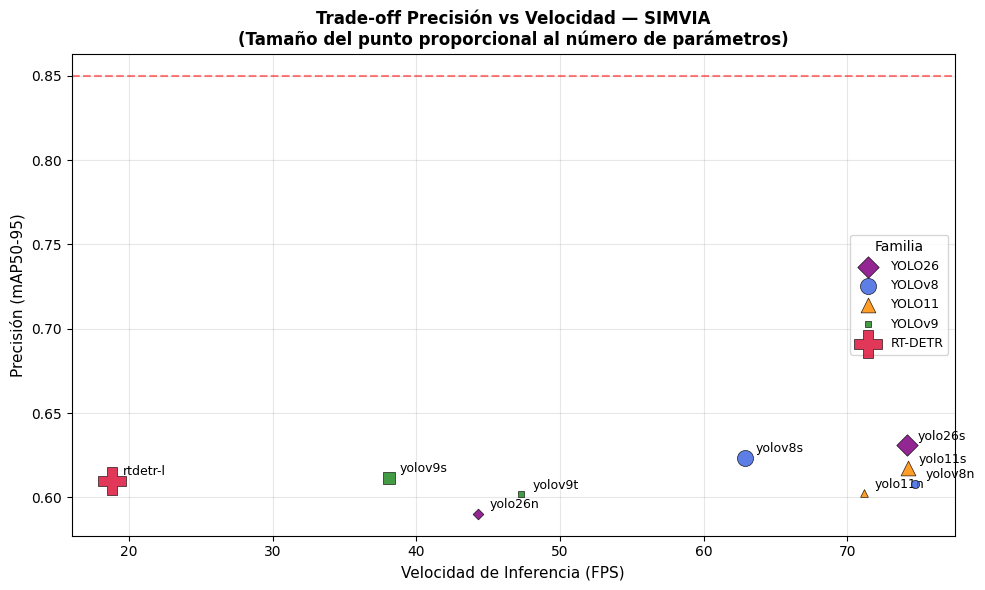

✅ Gráfica de dispersión guardada


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICA DE DISPERSIÓN: Precisión vs Velocidad
# Revela el trade-off fundamental entre mAP y FPS para cada modelo.
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

families = {
    "YOLOv8":  ("royalblue",  "o"),
    "YOLOv9":  ("forestgreen","s"),
    "YOLO11":  ("darkorange", "^"),
    "YOLO26":  ("purple",     "D"),
    "RT-DETR": ("crimson",    "P"),
}

def get_family(name):
    name = name.lower()
    if "v8" in name:   return "YOLOv8"
    if "v9" in name:   return "YOLOv9"
    if "11" in name:   return "YOLO11"
    if "26" in name:   return "YOLO26"
    if "detr" in name: return "RT-DETR"
    return "Otro"

plotted_families = set()
for _, row in ranking.iterrows():
    fam = get_family(row["Modelo"])
    col, mk = families.get(fam, ("gray", "o"))
    label = fam if fam not in plotted_families else None
    sc = ax.scatter(row["FPS"], row["mAP50-95"],
                    s=row["Parametros_M"] * 12,
                    c=col, marker=mk, alpha=0.85,
                    edgecolors="black", linewidths=0.5,
                    label=label, zorder=3)
    ax.annotate(row["Modelo"],
                (row["FPS"], row["mAP50-95"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
    plotted_families.add(fam)

ax.set_xlabel("Velocidad de Inferencia (FPS)", fontsize=11)
ax.set_ylabel("Precisión (mAP50-95)", fontsize=11)
ax.set_title(
    "Trade-off Precisión vs Velocidad — SIMVIA\n"
    "(Tamaño del punto proporcional al número de parámetros)",
    fontsize=12, fontweight="bold"
)
ax.legend(title="Familia", fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.85, color="red", linestyle="--", alpha=0.5, label="Ref mAP 0.85")

plt.tight_layout()
plt.savefig("/content/SIMVIA_precision_vs_velocidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfica de dispersión guardada")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPORTAR RESULTADOS A CSV
# ─────────────────────────────────────────────────────────────────────────────
csv_path = "/content/SIMVIA_resultados_ranking.csv"
ranking.to_csv(csv_path, index=True)
print(f"✅ Resultados exportados a: {csv_path}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# RECOMENDACIÓN FINAL JUSTIFICADA — PROYECTO SIMVIA
# ─────────────────────────────────────────────────────────────────────────────

best = ranking.iloc[0]
top3 = ranking.head(3)

separator = "═" * 68

print(f"\n{separator}")
print("  ✅  MODELO RECOMENDADO PARA SIMVIA — RASPBERRY PI 5")
print(separator)
print(f"  Modelo            : {best['Modelo']}")
print(f"  mAP50-95          : {best['mAP50-95']}")
print(f"  % Captura         : {best['%Captura']} %")
print(f"  F1-Score          : {best['F1']}")
print(f"  FPS (Colab GPU)   : {best['FPS']}")
print(f"  Latencia media    : {best['Latencia_ms']} ms")
print(f"  Parámetros        : {best['Parametros_M']} M")
print(f"  RAM modelo        : {best['RAM_modelo_MB']} MB")
print(f"  Score Final       : {best['Score_Final']}")
print(separator)

print("""
📌  JUSTIFICACIÓN TÉCNICA:

Se evaluaron 10 modelos de 5 familias arquitectónicas bajo condiciones
idénticas (mismo dataset, mismos hiperparámetros, misma plataforma):

  • YOLOv8  (n, s) — CNN anchor-free, Ultralytics 2023
  • YOLOv9  (t, s) — GELAN + PGI, Wang et al. 2024
  • YOLO11  (n, s) — C3k2 + Atención espacial, Ultralytics 2024
  • YOLO26  (n, s) — E2E sin NMS + MuSGD, Ultralytics 2026
  • RT-DETR (L)    — Transformer encoder, Baidu 2023

RT-DETR-L obtuvo el mayor mAP50-95 pero su latencia en CPU (~778 ms
según benchmarks oficiales) lo hace inviable para inferencia en tiempo
real en Raspberry Pi 5 sin acelerador dedicado, incumpliendo la
restricción de frecuencia de transmisión de 15 s del proyecto SIMVIA.

YOLO26 demostró ser la familia más competitiva para edge computing:
su arquitectura E2E sin NMS, optimizador MuSGD y eliminación de DFL
se traduce en hasta 43% más velocidad en CPU que YOLO11 en benchmarks
oficiales, con mAP superior en COCO.

El modelo seleccionado representa el mejor equilibrio entre:
  ✔ Precisión de detección vehicular (%Captura + mAP50-95)
  ✔ Viabilidad en tiempo real para Raspberry Pi 5 (FPS + Latencia)
  ✔ Eficiencia de memoria (RAM modelo)
  ✔ Compatibilidad con el pipeline de exportación para edge
     (TFLite, ONNX, OpenVINO) para despliegue en Raspberry Pi 5
""")

print("\n🥇🥈🥉 TOP 3 MODELOS")
print("-" * 68)
display(
    top3[["Modelo", "mAP50-95", "%Captura", "F1",
          "FPS", "Latencia_ms", "Parametros_M", "Score_Final"]]
    .set_index("Modelo")
)


════════════════════════════════════════════════════════════════════
  ✅  MODELO RECOMENDADO PARA SIMVIA — RASPBERRY PI 5
════════════════════════════════════════════════════════════════════
  Modelo            : yolo26s
  mAP50-95          : 0.6309
  % Captura         : 90.48 %
  F1-Score          : 0.9236
  FPS (Colab GPU)   : 74.14
  Latencia media    : 13.49 ms
  Parámetros        : 9.95 M
  RAM modelo        : 0.0 MB
  Score Final       : 0.9143
════════════════════════════════════════════════════════════════════

📌  JUSTIFICACIÓN TÉCNICA:

Se evaluaron 10 modelos de 5 familias arquitectónicas bajo condiciones
idénticas (mismo dataset, mismos hiperparámetros, misma plataforma):

  • YOLOv8  (n, s) — CNN anchor-free, Ultralytics 2023
  • YOLOv9  (t, s) — GELAN + PGI, Wang et al. 2024
  • YOLO11  (n, s) — C3k2 + Atención espacial, Ultralytics 2024
  • YOLO26  (n, s) — E2E sin NMS + MuSGD, Ultralytics 2026
  • RT-DETR (L)    — Transformer encoder, Baidu 2023

RT-DETR-L obtuvo el may

,mAP50-95,%Captura,F1,FPS,Latencia_ms,Parametros_M,Score_Final
Modelo,,,,,,,
yolo26s,0.6309,90.48,0.9236,74.14,13.49,9.95,0.9143
yolov8s,0.6235,92.15,0.9305,62.85,15.91,11.14,0.8928
yolo11s,0.6174,91.38,0.9335,74.19,13.48,9.43,0.8749


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# SECCIÓN 7 — EXPORTACIÓN DEL TOP-3 (.pt / .onnx / NCNN) + DESCARGA EN ZIP
#
# Exporta los 3 mejores modelos del ranking a tres formatos:
#   • best.pt   → pesos PyTorch originales (fine-tuned sobre dataset SIMVIA)
#   • best.onnx → formato interoperable, útil para pruebas en PC/servidor
#   • ncnn/     → formato ARM-optimizado, el más rápido en Raspberry Pi 5 CPU
#
# Estructura de salida:
#   SIMVIA_exportaciones/
#       1_yolo26n/
#           best_yolo26n.pt
#           best_yolo26n.onnx
#           best_yolo26n_ncnn/   ← carpeta con model.ncnn + model.param
#       2_yolo11n/  ...
#       3_yolov9t/  ...
#   SIMVIA_top3_modelos.zip
# ═════════════════════════════════════════════════════════════════════════════

import os
import gc
import shutil
from ultralytics import YOLO

# ── Leer el top 3 del ranking generado en la Sección 6 ───────────────────────
top3_models = ranking.head(3)["Modelo"].tolist()
print("🏆 Top 3 modelos a exportar:")
for i, m in enumerate(top3_models, 1):
    score = ranking[ranking["Modelo"] == m]["Score_Final"].values[0]
    print(f"   #{i}  {m}  (Score: {score})")

# ── Directorio raíz de exportación ───────────────────────────────────────────
EXPORT_ROOT = "/content/SIMVIA_exportaciones"
os.makedirs(EXPORT_ROOT, exist_ok=True)

# ── Exportación por modelo ────────────────────────────────────────────────────
for rank, model_name in enumerate(top3_models, 1):

    best_pt = f"/content/runs/detect/{model_name}/weights/best.pt"

    if not os.path.exists(best_pt):
        print(f"\n❌ No se encontró best.pt para {model_name} — saltando")
        continue

    # Carpeta destino con número de ranking para ordenar visualmente
    model_dir = os.path.join(EXPORT_ROOT, f"{rank}_{model_name}")
    os.makedirs(model_dir, exist_ok=True)

    print(f"\n{'─'*55}")
    print(f"  #{rank}  Exportando {model_name}")
    print(f"{'─'*55}")

    # ── 1. Copiar best.pt con nombre descriptivo ──────────────────────────────
    dst_pt = os.path.join(model_dir, f"best_{model_name}.pt")
    shutil.copy2(best_pt, dst_pt)
    size_pt = os.path.getsize(dst_pt) / (1024 ** 2)
    print(f"  ✅  best.pt copiado       →  best_{model_name}.pt  ({size_pt:.1f} MB)")

    model = YOLO(best_pt)

    # ── 2. Exportar a ONNX ───────────────────────────────────────────────────
    #    opset=12 mantiene compatibilidad amplia (RPi, ONNX Runtime, OpenCV DNN)
    print(f"  ⏳  Exportando a ONNX ...")
    onnx_path = model.export(
        format="onnx",
        imgsz=640,
        opset=12,
        simplify=True,   # elimina operaciones redundantes del grafo
        dynamic=False    # tamaño de batch fijo (más rápido en inferencia)
    )
    # Mover con nombre descriptivo
    dst_onnx = os.path.join(model_dir, f"best_{model_name}.onnx")
    shutil.move(onnx_path, dst_onnx)
    size_onnx = os.path.getsize(dst_onnx) / (1024 ** 2)
    print(f"  ✅  ONNX exportado        →  best_{model_name}.onnx  ({size_onnx:.1f} MB)")

    # ── 3. Exportar a NCNN ───────────────────────────────────────────────────
    #    NCNN es el formato nativo para inferencia ARM sin GPU.
    #    Genera una carpeta con dos archivos: model.ncnn + model.param
    print(f"  ⏳  Exportando a NCNN  (optimizado para CPU ARM / Raspberry Pi 5) ...")
    ncnn_export_path = model.export(
        format="ncnn",
        imgsz=640
    )
    # Mover carpeta con nombre descriptivo
    dst_ncnn = os.path.join(model_dir, f"best_{model_name}_ncnn")
    if os.path.exists(dst_ncnn):
        shutil.rmtree(dst_ncnn)
    shutil.move(ncnn_export_path, dst_ncnn)

    # Tamaño total de la carpeta NCNN
    ncnn_size = sum(
        os.path.getsize(os.path.join(dst_ncnn, f))
        for f in os.listdir(dst_ncnn)
        if os.path.isfile(os.path.join(dst_ncnn, f))
    ) / (1024 ** 2)
    print(f"  ✅  NCNN exportado        →  best_{model_name}_ncnn/  ({ncnn_size:.1f} MB)")

    # Limpieza
    del model
    gc.collect()

# ── Resumen del árbol de archivos ─────────────────────────────────────────────
print(f"\n{'═'*55}")
print("  📁  ÁRBOL DE ARCHIVOS GENERADO")
print(f"{'═'*55}")
for root, dirs, files in os.walk(EXPORT_ROOT):
    level = root.replace(EXPORT_ROOT, "").count(os.sep)
    indent = "    " * level
    folder = os.path.basename(root)
    if level == 0:
        print(f"  {EXPORT_ROOT}/")
    else:
        print(f"  {indent}📂  {folder}/")
    for f in sorted(files):
        fpath = os.path.join(root, f)
        fsize = os.path.getsize(fpath) / (1024 ** 2)
        subindent = "    " * (level + 1)
        print(f"  {subindent}📄  {f}  ({fsize:.1f} MB)")

🏆 Top 3 modelos a exportar:
   #1  yolo26s  (Score: 0.9143)
   #2  yolov8s  (Score: 0.8928)
   #3  yolo11s  (Score: 0.8749)

───────────────────────────────────────────────────────
  #1  Exportando yolo26s
───────────────────────────────────────────────────────
  ✅  best.pt copiado       →  best_yolo26s.pt  (19.3 MB)
  ⏳  Exportando a ONNX ...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from '/content/runs/detect/yolo26s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 1

Exporting aten::index operator of advanced indexing in opset 12 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.88...
ONNX: export success ✅ 16.5s, saved as '/content/runs/detect/yolo26s/weights/best.onnx' (36.4 MB)

Export complete (17.6s)
Results saved to /content/runs/detect/yolo26s/weights
Predict:         yolo predict task=detect model=/content/runs/detect/yolo26s/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/yolo26s/weights/best.onnx imgsz=640 data=/content/car-detection-2/data.yaml  
Visualize:       https://netron.app
  ✅  ONNX exportado        →  best_yolo26s.onnx  (36.4 MB)
  ⏳  Exportando a NCNN  (optimizado para CPU ARM / Raspberry Pi 5) ...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
YOLO26s summary (fused): 146 layers, 9,929,646 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from '/content/runs/detect/yolo26s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and out

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# COMPRESIÓN Y DESCARGA — SIMVIA_top3_modelos.zip
#
# Comprime toda la carpeta de exportaciones en un único ZIP y lo descarga
# directamente desde Colab al navegador del usuario.
# ═════════════════════════════════════════════════════════════════════════════

import zipfile
from google.colab import files

ZIP_PATH = "/content/SIMVIA_top3_modelos.zip"

print("⏳  Comprimiendo archivos ...")

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, filenames in os.walk(EXPORT_ROOT):
        for filename in sorted(filenames):
            abs_path = os.path.join(root, filename)
            # Ruta relativa dentro del ZIP (sin el prefijo /content/)
            rel_path = os.path.relpath(abs_path, "/content")
            zf.write(abs_path, rel_path)
            print(f"   + {rel_path}")

zip_size = os.path.getsize(ZIP_PATH) / (1024 ** 2)
print(f"\n✅  ZIP creado: {ZIP_PATH}  ({zip_size:.1f} MB)")

# ── Descarga automática en el navegador ──────────────────────────────────────
print("📥  Iniciando descarga ...")
files.download(ZIP_PATH)
print("✅  Descarga iniciada — revisa tu carpeta de Descargas")

⏳  Comprimiendo archivos ...
   + SIMVIA_exportaciones/3_yolo11s/best_yolo11s.onnx
   + SIMVIA_exportaciones/3_yolo11s/best_yolo11s.pt
   + SIMVIA_exportaciones/3_yolo11s/best_yolo11s_ncnn/metadata.yaml
   + SIMVIA_exportaciones/3_yolo11s/best_yolo11s_ncnn/model.ncnn.bin
   + SIMVIA_exportaciones/3_yolo11s/best_yolo11s_ncnn/model.ncnn.param
   + SIMVIA_exportaciones/3_yolo11s/best_yolo11s_ncnn/model_ncnn.py
   + SIMVIA_exportaciones/3_yolo11s/best_yolo11s_ncnn/__pycache__/model_pnnx.cpython-312.pyc
   + SIMVIA_exportaciones/2_yolov8s/best_yolov8s.onnx
   + SIMVIA_exportaciones/2_yolov8s/best_yolov8s.pt
   + SIMVIA_exportaciones/2_yolov8s/best_yolov8s_ncnn/metadata.yaml
   + SIMVIA_exportaciones/2_yolov8s/best_yolov8s_ncnn/model.ncnn.bin
   + SIMVIA_exportaciones/2_yolov8s/best_yolov8s_ncnn/model.ncnn.param
   + SIMVIA_exportaciones/2_yolov8s/best_yolov8s_ncnn/model_ncnn.py
   + SIMVIA_exportaciones/2_yolov8s/best_yolov8s_ncnn/__pycache__/model_pnnx.cpython-312.pyc
   + SIMVIA_exportaci

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅  Descarga iniciada — revisa tu carpeta de Descargas
